In [1]:
import pandas as pd

df = pd.read_csv("Unemployment in India.csv")

print(df.shape)
print(df.columns)

(768, 7)
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')


In [2]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')


In [3]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [4]:
df = df.dropna(how="all")

print(df.shape)
print(df.isnull().sum())

(740, 7)
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [5]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

print(df["Date"].dtype)
print(df["Date"].min())
print(df["Date"].max())

datetime64[us]
2019-05-31 00:00:00
2020-06-30 00:00:00


In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 46.2 KB


In [7]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


## Exploratory Data Analysis

The dataset contains unemployment information for different regions of India from May 2019 to June 2020. The analysis focuses on unemployment rates, employment levels, labour participation, regional differences, and changes during the COVID-19 period.

We will first examine the overall statistical summary and then investigate regional and temporal trends using visualizations.

In [8]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [9]:
region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
)

region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

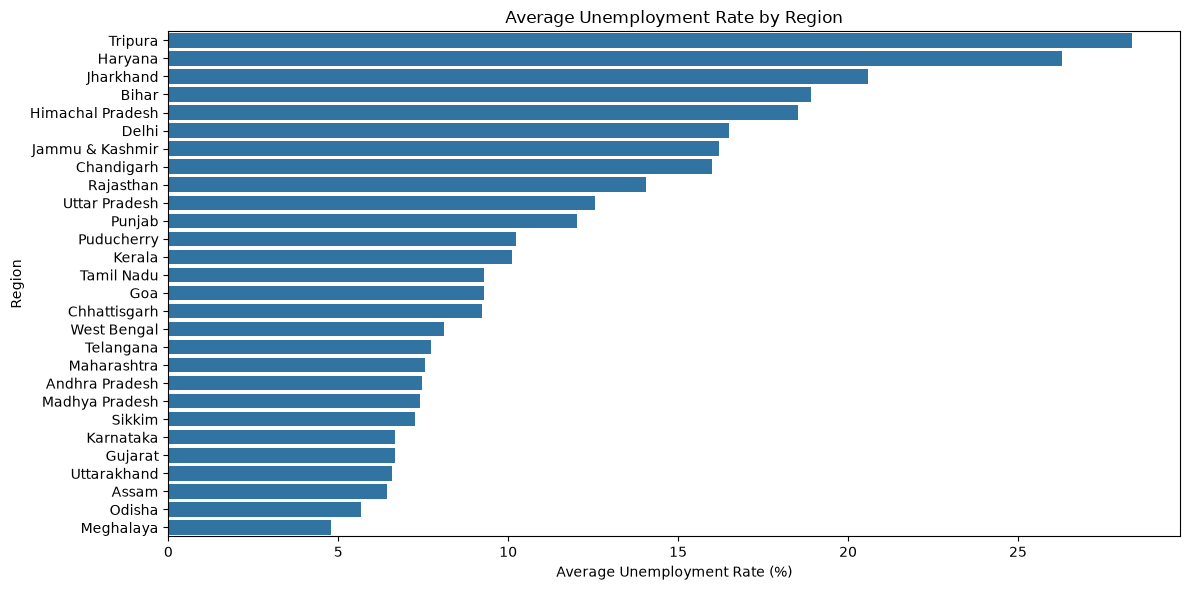

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.barplot(
    x=region_avg.values,
    y=region_avg.index
)

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

### Observation

The average unemployment rate varies considerably across different regions of India. Some regions consistently experienced higher unemployment rates than others during the period covered by the dataset. This indicates that unemployment was not evenly distributed geographically.

In [11]:
monthly_avg = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_index()
)

monthly_avg

Date
2019-05-31     8.874259
2019-06-30     9.303333
2019-07-31     9.033889
2019-08-31     9.637925
2019-09-30     9.051731
2019-10-31     9.900909
2019-11-30     9.868364
2019-12-31     9.497358
2020-01-31     9.950755
2020-02-29     9.964717
2020-03-31    10.700577
2020-04-30    23.641569
2020-05-31    24.875294
2020-06-30    11.903600
Name: Estimated Unemployment Rate (%), dtype: float64

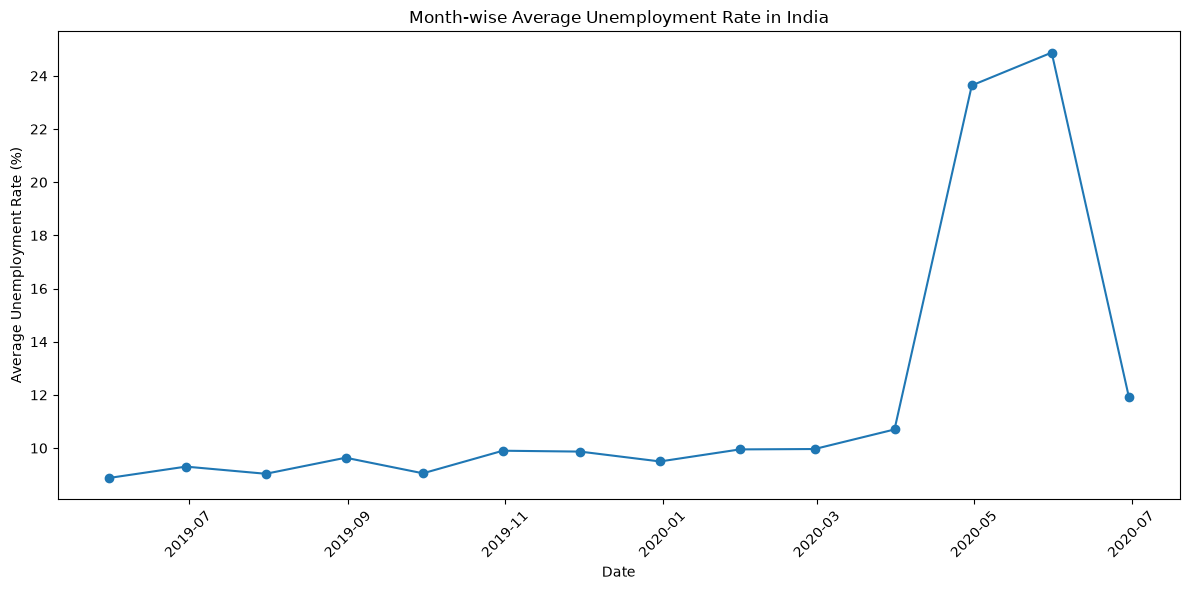

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o"
)

plt.title("Month-wise Average Unemployment Rate in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The unemployment rate shows noticeable variation over time. The trend becomes particularly important around early 2020, when the COVID-19 pandemic and related restrictions affected economic activity and employment across India.

In [13]:
df["Region"].unique()

<StringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal',
       'Chandigarh']
Length: 28, dtype: str

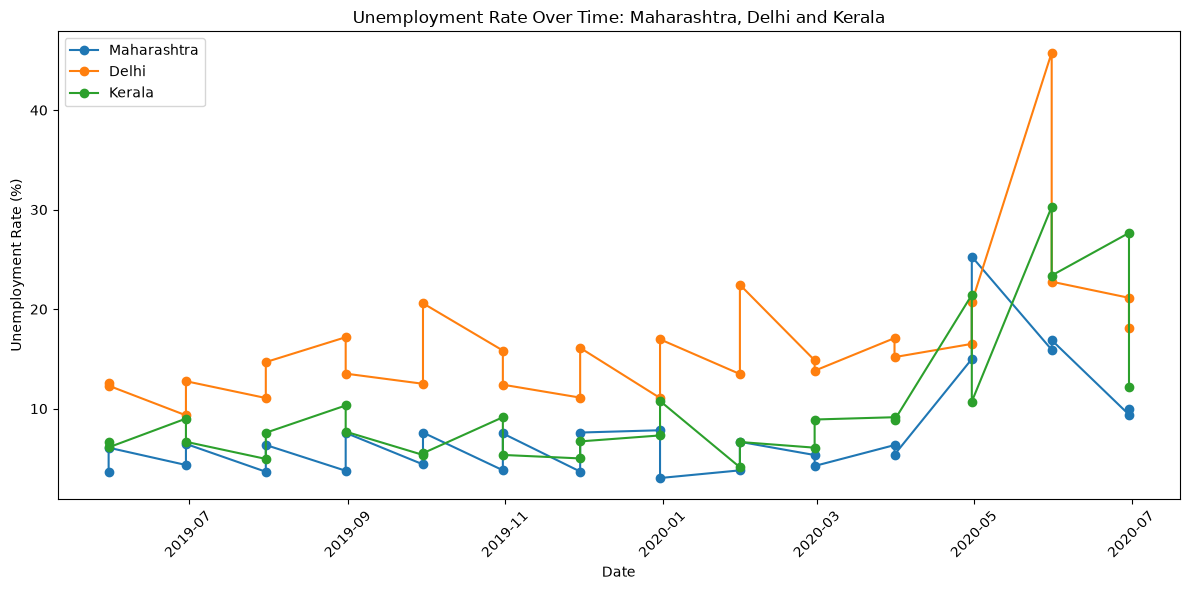

In [14]:
selected_regions = ["Maharashtra", "Delhi", "Kerala"]

plt.figure(figsize=(12, 6))

for region in selected_regions:
    region_data = df[df["Region"] == region].sort_values("Date")
    
    plt.plot(
        region_data["Date"],
        region_data["Estimated Unemployment Rate (%)"],
        marker="o",
        label=region
    )

plt.title("Unemployment Rate Over Time: Maharashtra, Delhi and Kerala")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The three selected regions show different unemployment patterns over time. The unemployment rate fluctuates across the period, with noticeable changes around 2020. The differences between the regions indicate that the impact of economic disruptions was not identical across India.

In [15]:
top_10_regions = region_avg.head(10)

top_10_regions

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64

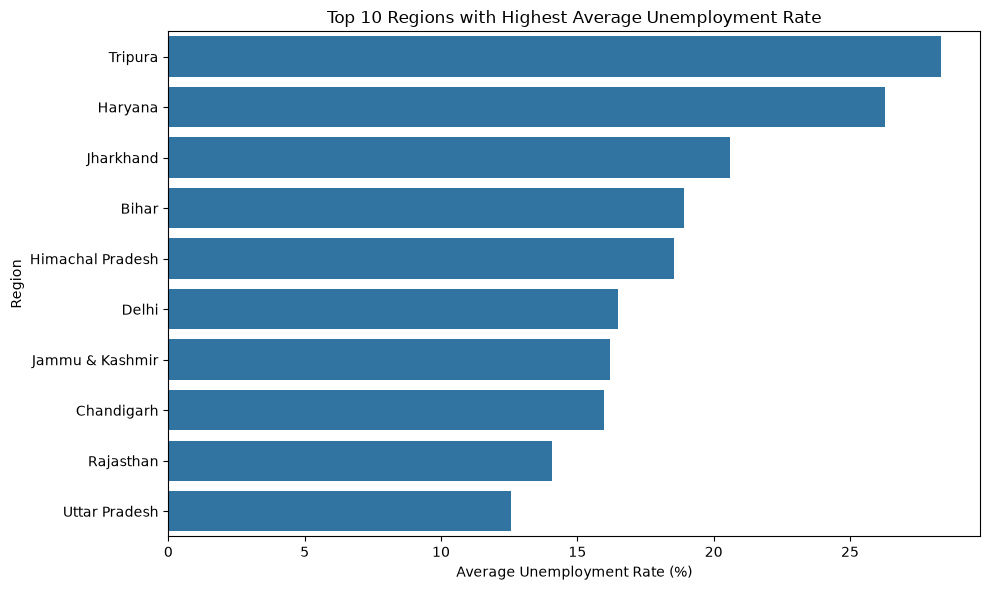

In [16]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_regions.values,
    y=top_10_regions.index
)

plt.title("Top 10 Regions with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

### Observation

The top 10 regions show the highest average unemployment rates during the period analyzed. These regions experienced relatively greater unemployment compared with the other regions in the dataset, highlighting significant regional differences in employment conditions.

In [17]:
correlation_data = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


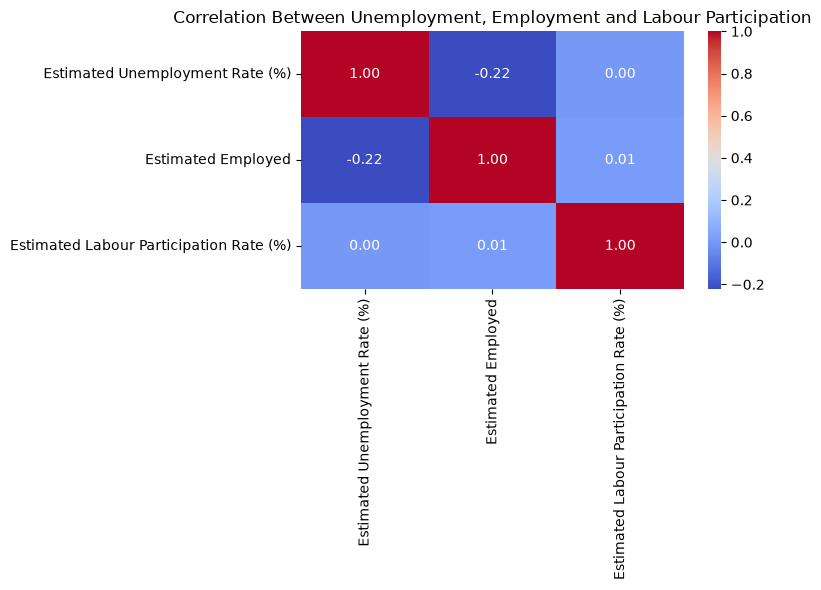

In [18]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Unemployment, Employment and Labour Participation")
plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows the strength and direction of relationships among unemployment rate, estimated employment, and labour participation rate. Positive values indicate that two variables tend to increase together, while negative values indicate an inverse relationship. The heatmap helps identify which employment-related measures are most strongly associated with unemployment.

In [19]:
pre_covid = df[df["Date"] < "2020-03-01"]
post_covid = df[df["Date"] >= "2020-03-01"]

print("Pre-COVID rows:", len(pre_covid))
print("Post-COVID rows:", len(post_covid))

Pre-COVID rows: 536
Post-COVID rows: 204


In [20]:
comparison = pd.DataFrame({
    "Pre-COVID": [
        pre_covid["Estimated Unemployment Rate (%)"].mean(),
        pre_covid["Estimated Employed"].mean(),
        pre_covid["Estimated Labour Participation Rate (%)"].mean()
    ],
    "Post-COVID": [
        post_covid["Estimated Unemployment Rate (%)"].mean(),
        post_covid["Estimated Employed"].mean(),
        post_covid["Estimated Labour Participation Rate (%)"].mean()
    ]
}, index=[
    "Unemployment Rate (%)",
    "Estimated Employed",
    "Labour Participation Rate (%)"
])

comparison

,Pre-COVID,Post-COVID
Unemployment Rate (%),9.509534e+00,1.777436e+01
Estimated Employed,7.466028e+06,6.517203e+06
Labour Participation Rate (%),4.388612e+01,3.933005e+01


### Pre-COVID vs Post-COVID Comparison

The data is divided into two periods using March 2020 as the beginning of the COVID-19 period. Comparing the average values helps identify how unemployment, employment, and labour participation changed during the early stage of the pandemic.

### Observation

The comparison shows a clear change in employment conditions during the COVID-19 period. The average unemployment rate increased from approximately 9.51% before COVID-19 to 17.77% during the post-COVID period. At the same time, average estimated employment decreased from approximately 7.47 million to 6.52 million, while labour participation decreased from 43.89% to 39.33%.

These changes indicate that the COVID-19 pandemic and associated economic restrictions were associated with a substantial increase in unemployment and a decline in employment and labour participation during the period covered by the dataset.

## Conclusion

This analysis explored unemployment trends across different regions of India from May 2019 to June 2020. The analysis showed significant differences in average unemployment rates between regions and noticeable changes over time.

The comparison between the pre-COVID and post-COVID periods showed that the average unemployment rate increased substantially during the COVID-19 period, while estimated employment and labour participation decreased. This highlights the significant impact that the pandemic and associated economic restrictions had on employment conditions in India.

Overall, the analysis demonstrates the usefulness of exploratory data analysis and data visualization for identifying regional and temporal patterns in unemployment data.

## Key Findings

- Unemployment rates varied considerably across Indian regions.
- Unemployment showed noticeable changes over the period from 2019 to 2020.
- The selected regions displayed different unemployment patterns over time.
- The top 10 regions had substantially higher average unemployment rates than other regions.
- The correlation analysis revealed relationships between unemployment, employment, and labour participation.
- Average unemployment increased from approximately **9.51% pre-COVID to 17.77% during the post-COVID period**.
- Average estimated employment and labour participation decreased during the post-COVID period.